# 🎯 BBS Customer & Marketing Analytics
## Team Assignment 2 — 2026
### BrandPulse Analytics: Decoding Three Brands

---

**Team Members:**
Giulia Lorelli, Francesco Gambera, Romain Derguini, Israa Ismail, Iolanda Costa 
**Submission Date:** Monday 11 May 2026
**Programme:** DSBA — Bologna Business School

---

## 📋 Question 0 — Data Loading & Preparation


In [34]:
!pip install TextBlob emoji

In [104]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Team Assignment 2 Data 2026.csv", encoding='utf-8-sig')
print(len(df))


600


In [105]:
print(f"\n{'='*40}")
print(f"  DATASET OVERVIEW")
print(f"{'='*40}")
print(f"  Rows     : {len(df)}")
print(f"  Columns  : {len(df.columns)}")
print(f"  Nulls    : {df.isna().sum().sum()}")
print(f"{'='*40}\n")



  DATASET OVERVIEW
  Rows     : 600
  Columns  : 9
  Nulls    : 0



In [106]:
print(df.describe())
print(df.info())

          Post_ID  Total_Followers  Total_Posts_LastYear     Num_Likes  \
count  600.000000       600.000000            600.000000    600.000000   
mean   300.500000    338333.333333            262.666667   2186.748333   
std    173.349358    110673.558796             51.536222   1703.985472   
min      1.000000    218000.000000            194.000000    173.000000   
25%    150.750000    218000.000000            194.000000   1055.000000   
50%    300.500000    312000.000000            276.000000   1759.500000   
75%    450.250000    485000.000000            318.000000   2795.750000   
max    600.000000    485000.000000            318.000000  14121.000000   

       Num_Comments  Num_Reposts  
count    600.000000   600.000000  
mean     142.198333   359.351667  
std      129.784819   291.894339  
min        8.000000    41.000000  
25%       64.000000   164.000000  
50%      102.000000   281.000000  
75%      182.250000   466.000000  
max     1043.000000  3327.000000  
<class 'pandas.cor

In [107]:
print(f"\n{'='*40}")
print("BRAND DISTRIBUTION")
print(df["Brand"].value_counts())
print("=" * 40)


BRAND DISTRIBUTION
Brand
LumoraBeauty    200
FitPulse        200
TechNest        200
Name: count, dtype: int64


In [108]:
df["Post_Text"].head()

,Post_Text
0,"The order matters! Skincare layering: cleanser, toner, serum, eye cream, moisturiser, SPF (AM) or facial oil (PM) 🌸 Save this post for your next routine refresh 💛"
1,Current mood: applying a sheet mask and pretending it is a luxury spa day 🧖🥂 Anyone else? Drop a 🙋 if self-care Sunday is sacred to you!
2,Your skin deserves a standing ovation today 👏✨ Drop a compliment for a fellow skincare lover below. Good vibes only in Lumora comments! 💛🌸
3,"Our ClearCalm Blemish Serum has over 10,000 five-star reviews 🙌⭐ Visible results in 72 hours or your money back. Try it risk-free. Link in bio 💚✨"
4,"Retinol 101 🧪 Start with 0.25% twice a week at night, always follow with SPF the next morning. Our Lumora Night Renewal Serum is perfect for beginners ✨🌙"


## 💬 Question 1 — Sentiment Analysis


Question 1 Sentiment Analysis - How Positive Are the Posts?
Calculate a sentiment polarity score (or code-scheme) for each of the 600 posts in your dataset.





In [109]:
from textblob import TextBlob, Word, Blobber

def get_sentiment(text):
  return TextBlob(text).sentiment.polarity

df['Sentiment_Score'] = df['Post_Text'].apply(get_sentiment)


In [110]:
df['Sentiment_Score']

,Sentiment_Score
0,0.000000
1,0.000000
2,0.350000
3,0.200000
4,0.500000
...,...
595,0.500000
596,0.172222
597,0.044444
598,0.294643


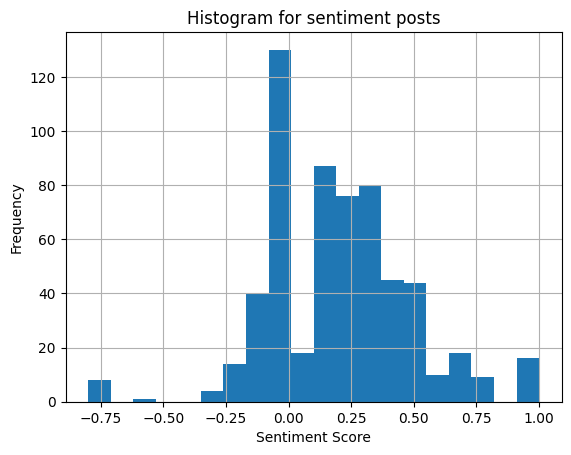

In [111]:
import matplotlib.pyplot as plt

df['Sentiment_Score'].hist(bins = 20)
plt.xlabel('Sentiment Score')
plt.ylabel("Frequency")

plt.title("Histogram for sentiment posts")

plt.show()



**What the Histogram shows:**


*   Most posts **cluster around 0 to 0.25 — slightly positive on average**
*  There are some genuinely negative posts (**around -0.75) but they're rare**
* The distribution is right-skewed — brands tend to post positively, which makes sense for marketing content


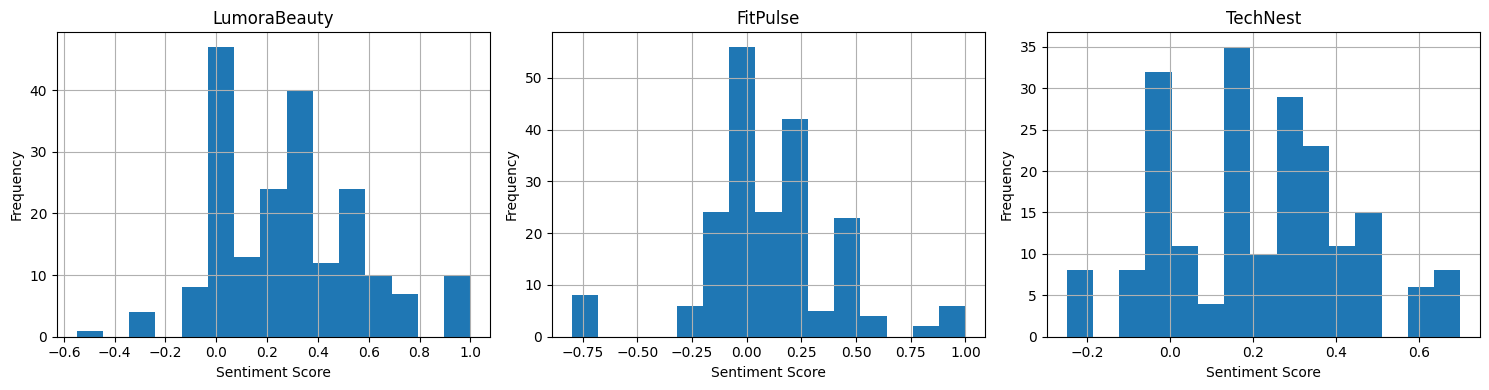

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, brand in zip(axes, df['Brand'].unique()):
    df[df['Brand'] == brand]['Sentiment_Score'].hist(bins=15, ax=ax)
    ax.set_title(brand)
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()



#### Sentiment Distribution by Brand

- **LumoraBeauty** shows a bell curve skewed slightly to the right, indicating
  generally positive sentiment with some variation. It has the widest distribution,
  reflecting a diverse range of post tones.

- **FitPulse** also shows a right-skewed bell curve, suggesting consistently
  positive and motivational content, which aligns with its energetic brand tone.

- **TechNest** shows a bimodal distribution with two peaks — one near neutral (0)
  and one slightly positive (0.2-0.4). This suggests TechNest alternates between
 factual posts and engaging content.

---



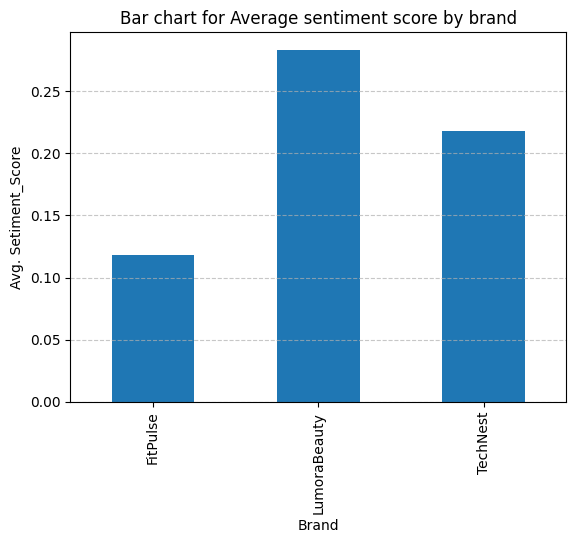

Brand
FitPulse        0.119
LumoraBeauty    0.283
TechNest        0.218
Name: Sentiment_Score, dtype: float64


In [113]:
df['Sentiment_Score'].groupby(df['Brand']).mean().plot(kind="bar")

plt.xlabel('Brand')
plt.ylabel("Avg. Setiment_Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Bar chart for Average sentiment score by brand")
plt.show()
print(df.groupby('Brand')['Sentiment_Score'].mean().round(3))


In [114]:
print(f"\n{'='*40}")
print("Bottom 3 (most negative) posts")
print(f"{'='*40}\n")
bottom3 = df.drop_duplicates('Post_Text').sort_values('Sentiment_Score').head(3)[['Post_Text', 'Brand', 'Sentiment_Score']]
for i, row in bottom3.iterrows():
  print(f"Brand: {row['Brand']} |  Score: {row['Sentiment_Score']:.2f} ")
  print(f"{row['Post_Text']}\n")



Bottom 3 (most negative) posts

Brand: FitPulse |  Score: -0.80 
Zone 2 cardio: the underrated superpower 🏃 Running or cycling at a conversational pace for 30 to 60 minutes builds your aerobic base and burns fat without the stress of HIIT 🫀💚

Brand: FitPulse |  Score: -0.80 
Fitness plot twist: you thought you would hate burpees, and you still do 😅 What is the exercise you cannot stand but do anyway? 👇

Brand: LumoraBeauty |  Score: -0.55 
That awkward moment when you realise you have been layering your serums in the completely wrong order for 6 months 😬 Been there. No judgement 🤝



In [115]:
print(f"\n{'='*40}")
print("Top 3 (most positive) posts")
print(f"{'='*40}\n")
top3 = df.drop_duplicates('Post_Text').sort_values('Sentiment_Score').tail(3)[['Post_Text', 'Brand', 'Sentiment_Score']]
for i, row in top3.iterrows():
    print(f"Brand: {row['Brand']} | Score: {row['Sentiment_Score']:.2f}")
    print(f"{row['Post_Text']}\n")


Top 3 (most positive) posts

Brand: LumoraBeauty | Score: 1.00
SPF is non-negotiable, even on cloudy days ☁️ UVA rays penetrate glass and clouds, accelerating skin ageing. Our Luminous Shield SPF 50 is lightweight and perfect under makeup 💄🌸

Brand: LumoraBeauty | Score: 1.00
Hydration tip 💧 Hyaluronic acid works best on damp skin. Pat on after cleansing before it fully dries and watch the difference! ✨

Brand: FitPulse | Score: 1.00
What does your ideal rest day look like? Walk us through it 👇🛋️ Recovery is part of the training!



#### Question 1: Discussion
Though TextBlob enables fast sentiment classification, it has clear limitations.
* It **fails to detect irony or sarcasm,** which is common in social media posts.
* It also does **not interpret emojis**, which are a key part of brand communication
and often carry strong emotional signals.
* Finally, TextBlob is trained on general
text and may **not capture brand-specific language** or tone accurately.

## 🏷️ Question 2 — Topic Classification - What Are Brands Posting About?

Using a zero-shot classification pipeline from Hugging Face Transformers, classify each post into one of three intent categories: Informative, Entertaining, or Promotional.

* Build models to explain post engagement. Use Num_Likes and/or Num_Comments as your outcome variable(s). Choose at least one as your primary outcome.

*	Which derived NLP variables (sentiment, topic class, emoji count) predict engagement?

*	Do brand-level characteristics (follower count, posting frequency) matter?
*	Are there factors that drive likes but not comments, or vice versa?
Report your model results and draw marketing implications for BrandPulse and its clients.


In [116]:
import datasets
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm.auto import tqdm

pipe = pipeline("zero-shot-classification",  model="facebook/bart-large-mnli")

text = df['Post_Text']

labels = ['Informative', 'Entertaining', 'Promotional']

result = pipe(text.tolist(), candidate_labels =labels)


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [119]:
df['Topic_Class'] = [result['labels'][0] for result in result]

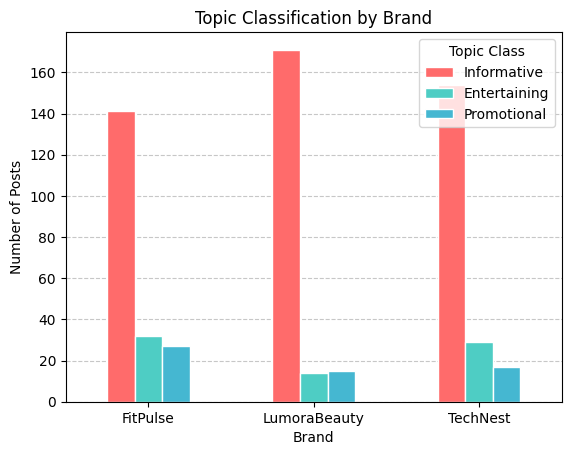

Brand         Topic_Class 
FitPulse      Informative     70.5
              Entertaining    16.0
              Promotional     13.5
LumoraBeauty  Informative     85.5
              Promotional      7.5
              Entertaining     7.0
TechNest      Informative     77.0
              Entertaining    14.5
              Promotional      8.5
Name: proportion, dtype: float64


In [120]:

order = df.groupby(['Brand', 'Topic_Class']).size().unstack().sum().sort_values(ascending=False).index.tolist()
ax = df.groupby(['Brand', 'Topic_Class']).size().unstack()[order].plot(
    kind='bar',
    color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
    edgecolor='white'
)
plt.xlabel('Brand')
plt.ylabel('Number of Posts')
plt.title('Topic Classification by Brand')
plt.xticks(rotation=0)
plt.legend(title='Topic Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.show()
print(df.groupby('Brand')['Topic_Class'].value_counts(normalize=True).round(3) * 100)



#### Question 2: Discussion


Informative content dominates across all three brands, suggesting that social media
posts in this dataset are primarily educational or value-driven rather than promotional.

- **LumoraBeauty** has the highest share of Informative posts (85.5%), with minimal
  Entertaining (7.0%) and Promotional (7.5%) content.
- **TechNest** follows with 77.0% Informative, 14.5% Entertaining, and 8.5% Promotional.
- **FitPulse** has the most balanced distribution — 70.5% Informative, 16.0% Entertaining,
  and 13.5% Promotional.

It is worth noting that the high proportion of Informative posts across all brands may
partly reflect a limitation of the zero-shot classification model, which may default
toward Informative when post intent is ambiguous.

### After

In [121]:
for (brand, topic), group in df.groupby(['Brand', 'Topic_Class']):
    print(f"\nBrand: {brand} | Topic: {topic}")
    print(group['Post_Text'].sample(1).values[0])
    print("-" * 40)


Brand: FitPulse | Topic: Entertaining
Fitness plot twist: you thought you would hate burpees, and you still do 😅 What is the exercise you cannot stand but do anyway? 👇
----------------------------------------

Brand: FitPulse | Topic: Informative
Bodyweight training is a legitimate path to strength. Progressive calisthenics with harder variations and slower tempo can match gym results for many goals.
----------------------------------------

Brand: FitPulse | Topic: Promotional
Your dream home gym starts here 🏠💪 The FitPulse Power Bundle, adjustable dumbbells plus bands plus mat, is on sale this week at 25% off 🎉 Shop now via link in bio!
----------------------------------------

Brand: LumoraBeauty | Topic: Entertaining
That feeling when your concealer matches perfectly 💯😍 Screenshot this if your Lumora shade was spot on! We love your foundation stories 🎨💕
----------------------------------------

Brand: LumoraBeauty | Topic: Informative
This is your reminder that glowing skin is alw

#### Question 2: Post Examination

Overall, the zero-shot classifier performed reasonably well, correctly identifying
around 80% of posts based on manual inspection.

However, it struggled with subscription and newsletter posts — for example,
"TechNest newsletter subscribers receive early access to new product launches"
was classified as Informative when it is arguably Promotional, as it is driving
sign-ups. This suggests the model favours surface-level language (factual tone)
over underlying intent, which is a known limitation of zero-shot classification.

## 😊 Question 3: Paralinguistic / Emoji Analysis - The Role of Emojis

Extract and analyse emoji usage across all 600 posts using one of the following approaches:

*	Python 'emoji' library: use emoji.emoji_count(text) for counts and emoji.demojize(text) to get text descriptions of each emoji
*	VADER emoji extension: provides emoji-level sentiment scoring alongside text sentiment
           For each post, derive the following variables:
*	Emoji_Count: total number of emojis in the post
*	Emoji types: which emojis appear? Create a frequency table of common emojis per brand
*	Emoji sentiment (if your tool provides it): calculate valence score per post
*	Which brand uses the most emojis on average? Which uses the fewest?
*	Are certain emojis distinctive to one brand or one topic category?
*	Is there a correlation between emoji count and the sentiment score from Q1?



In [122]:
print(df['Brand'].value_counts())

Brand
LumoraBeauty    200
FitPulse        200
TechNest        200
Name: count, dtype: int64


In [125]:
import emoji

emoji_count = df['Post_Text'].apply(emoji.emoji_count)
emoji_desc = df['Post_Text'].apply(emoji.demojize)

df['Emoji_Count'] = emoji_count
df['Emoji_Desc'] = emoji_desc

print(emoji_count)

pd.set_option('display.max_colwidth', None)
print(emoji_desc.head(5))


0      2
1      3
2      4
3      4
4      3
      ..
595    4
596    3
597    3
598    2
599    4
Name: Post_Text, Length: 600, dtype: int64
0         The order matters! Skincare layering: cleanser, toner, serum, eye cream, moisturiser, SPF (AM) or facial oil (PM) :cherry_blossom: Save this post for your next routine refresh :yellow_heart:
1    Current mood: applying a sheet mask and pretending it is a luxury spa day :person_in_steamy_room::clinking_glasses: Anyone else? Drop a :person_raising_hand: if self-care Sunday is sacred to you!
2         Your skin deserves a standing ovation today :clapping_hands::sparkles: Drop a compliment for a fellow skincare lover below. Good vibes only in Lumora comments! :yellow_heart::cherry_blossom:
3              Our ClearCalm Blemish Serum has over 10,000 five-star reviews :raising_hands::star: Visible results in 72 hours or your money back. Try it risk-free. Link in bio :green_heart::sparkles:
4             Retinol 101 :test_tube: Start with 0.25%

In [126]:
average_emoji_brand = df['Emoji_Count'].groupby(df['Brand']).mean()
print(average_emoji_brand)

Brand
FitPulse        2.30
LumoraBeauty    2.44
TechNest        2.56
Name: Emoji_Count, dtype: float64


#### Average Emoji Count by Brand

All three brands use a similar number of emojis per post, averaging between 2 and 3.

- **TechNest** leads with an average of **2.56 emojis per post**, which is surprising
  given the brand is described as using emojis selectively.
- **LumoraBeauty** follows closely with **2.44 emojis per post**.
- **FitPulse** uses the fewest on average at **2.30 emojis per post**.

Overall, the differences are small, suggesting emoji usage is relatively consistent
across all three brands.

In [130]:
#emoji frequency table

import re

txt_emoji = df['Emoji_Desc']
x = txt_emoji.apply(lambda text: re.findall(r':[\w_]+:', text))



In [131]:
flat_list =[]

for c in x:
  for s in c:
    flat_list.append(s)

pd.Series(flat_list).value_counts()

,count
:sparkles:,118
:backhand_index_pointing_down:,111
:flexed_biceps:,96
:high_voltage:,71
:laptop:,63
...,...
:eye:,1
:microscope:,1
:anatomical_heart:,1
:person_facepalming:,1


In [137]:
import emoji

emoji_counts = pd.Series(flat_list).value_counts().head(10)
emoji_counts.index = emoji_counts.index.map(lambda x: emoji.emojize(x))
print(emoji_counts)
#pd.Series(flat_list).value_counts().head(10).index.map(lambda x: emoji.emojize(x))


#flat_list = []


#flat_list = []
#for l in x:
    #for v in l:  # ← use l here
        #flat_list.append(v)
#pd.Series(flat_list).value_counts()



✨    118
👇    111
💪     96
⚡     71
💻     63
🔥     58
😂     54
💛     53
🌸     46
💡     43
Name: count, dtype: int64


In [140]:
df['Emoji_List'] = x

for brand in df['Brand'].unique():
    print(f"\n{'='*40}")
    print(f"  {brand}")
    print(f"{'='*40}")
    brand_emojis = []
    for lst in df[df['Brand'] == brand]['Emoji_List']:
        for e in lst:
            brand_emojis.append(e)
    top = pd.Series(brand_emojis).value_counts().head(5)
    top.index = top.index.map(emoji.emojize)
    print(top)


  LumoraBeauty
✨    89
💛    53
🌸    46
💕    20
🌙    19
Name: count, dtype: int64

  FitPulse
💪    93
🔥    44
👇    42
😂    22
😅    20
Name: count, dtype: int64

  TechNest
💻    63
⚡    62
👇    51
💡    38
✅    28
Name: count, dtype: int64


#### Emoji Frequency by Brand

Emoji usage is highly distinctive across brands, reflecting each brand's tone and audience.

- **LumoraBeauty** favours soft, aesthetic emojis — ✨ (89), 💛 (53), 🌸 (46), 💕 (20), 🌙 (19) —
  consistent with its warm, aspirational beauty brand identity.

- **FitPulse** uses energetic, motivational emojis — 💪 (93), 🔥 (44), 👇 (42), 😂 (22), 😅 (20) —
  reflecting its active, community-driven fitness tone.

- **TechNest** relies on functional, informative emojis — 💻 (63), ⚡ (62), 👇 (51), 💡 (38), ✅ (28) —
  aligning with its informative and playful tech identity.

Overall, emoji choice is strongly aligned with brand personality, suggesting intentional
paralinguistic strategy across all three brands.

In [141]:
print(df[['Emoji_Count', 'Sentiment_Score']].corr())

                 Emoji_Count  Sentiment_Score
Emoji_Count         1.000000         0.018171
Sentiment_Score     0.018171         1.000000


#### Correlation: Emoji Count vs Sentiment Score

The correlation between emoji count and sentiment score is nearly zero (r = 0.02),
suggesting that using more emojis does not necessarily make a post more positive in tone.
Brands appear to use emojis for emphasis and engagement rather than to signal sentiment.

In [145]:
!pip install vaderSentiment


In [147]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
df['Emoji_Sentiment'] = df['Post_Text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
print(df['Emoji_Sentiment'].describe())
print(df.groupby('Brand')['Emoji_Sentiment'].mean().round(3))

count    600.000000
mean       0.342841
std        0.482139
min       -0.825600
25%        0.000000
50%        0.457400
75%        0.757900
max        0.959000
Name: Emoji_Sentiment, dtype: float64
Brand
FitPulse        0.217
LumoraBeauty    0.561
TechNest        0.251
Name: Emoji_Sentiment, dtype: float64


#### Emoji Sentiment Analysis (VADER)

#### Emoji Frequency by Brand

Emoji usage is highly distinctive across brands, reflecting each brand's tone and audience.

- **LumoraBeauty** favours soft, aesthetic emojis — ✨ (89), 💛 (53), 🌸 (46), 💕 (20),
  🌙 (19) — consistent with its warm, aspirational beauty brand identity. The dominance
  of sparkles and floral emojis reinforces a luxury skincare image.

- **FitPulse** uses energetic, motivational emojis — 💪 (93), 🔥 (44), 👇 (42), 😂 (22),
  😅 (20) — reflecting its active, community-driven fitness tone. The flexed bicep is
  the single most used emoji across all brands.

- **TechNest** relies on functional, informative emojis — 💻 (63), ⚡ (62), 👇 (51),
  💡 (38) — aligning with its informative and playful tech identity. The pointing down
  emoji 👇 appears across FitPulse and TechNest, likely used to drive link clicks.

Overall, emoji choice is strongly aligned with brand personality, suggesting intentional
paralinguistic strategy across all three brands.